#Projeto NIDEC

###Importação de bibliotecas que serão utilizadas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Model
from tensorflow.keras.layers import Concatenate, Dense, Input, Embedding, Flatten
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [ ]:
##Garantindo que o resultado da rede seja sempre o mesmo
def reset_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # Para garantir determinismo total no TensorFlow (pode deixar o treino mais lento)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

reset_seeds(42)

###Importando o dataset



In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('CF02F23_220V_MP - Página1.csv')
df

Saving CF02F23_220V_MP - Página1.csv to CF02F23_220V_MP - Página1.csv


,Component geral,Voltage,Rotation,Power,Oven,Fence,Temperature
0,Power Switch - MOSFET IGB101 Tab,165.11,950,115.9,60.1,81.7,121.5
1,Power Switch - MOSFET IGB101 Tab,164.94,1706,184.1,60.1,81.5,126.4
2,Power Switch - MOSFET IGB101 Tab,165.06,2619,130.3,60.2,81.7,78.5
3,Power Switch - MOSFET IGB101 Tab,230.32,3591,120.1,60.1,81.8,71.9
4,Power Switch - MOSFET IGB101 Tab,230.27,3926,122.4,49.2,69.9,61.5
...,...,...,...,...,...,...,...
505,Cable - Motor Phase A\t-\t At the insulation -...,264.01,951,105.1,60.0,81.8,86.5
506,Cable - Motor Phase A\t-\t At the insulation -...,264.32,1569,169.7,60.1,81.7,90.5
507,Cable - Motor Phase A\t-\t At the insulation -...,264.22,2700,226.1,59.8,81.6,94.0
508,Cable - Motor Phase A\t-\t At the insulation -...,264.17,3490,265.4,60.0,81.6,96.1


####Plotando matriz de correlação para observar como as variáveis se relacionam

<Axes: >

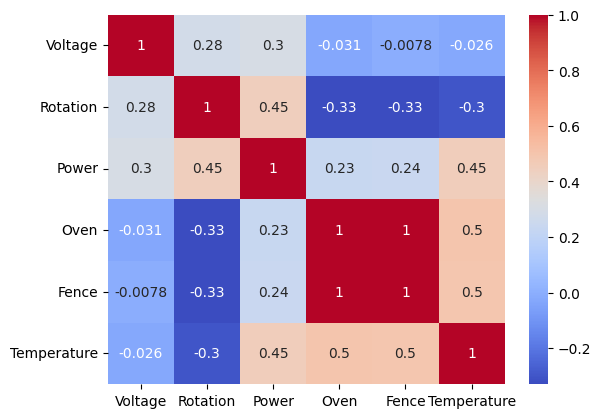

In [ ]:
sns.heatmap(df[['Voltage', 'Rotation','Power', 'Oven', 'Fence', 'Temperature' ]].corr(), cmap = 'coolwarm',annot=True)

- `Oven` e `Fence` são, praticamente, a mesma feature, por terem correlação igual a 1 e se relacionarem com as outras variáveis do mesmo jeito
 - Experimentos válidos incluem retirar uma das duas ou até uni-las
 - `Voltage` contribui muito pouco para a variável alvo talvez seja interessante retirar também

 **Obs**: o único teste que incrementou a performance do modelo foi retirar a feature `Fence`

###Análise de variáveis numéricas

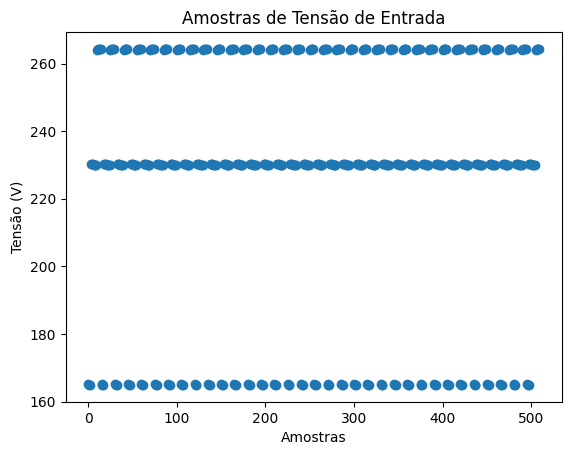

In [ ]:
a = df['Voltage'].tolist()
b = []

for i in range(len(a)):
  b.append(i)

plt.scatter(b,a)
plt.title('Amostras de Tensão de Entrada')
plt.xlabel('Amostras')
plt.ylabel('Tensão (V)')
plt.show()

Feature de tensão possui 3 faixas de atuação bem definidas, talvez seja isso que faça com que a feature não contribua tanto para o resultado final.

Pode ser interessante de escalá-la com MinMaxScaler e, em seguida, ver como o modelo performa sem ela.

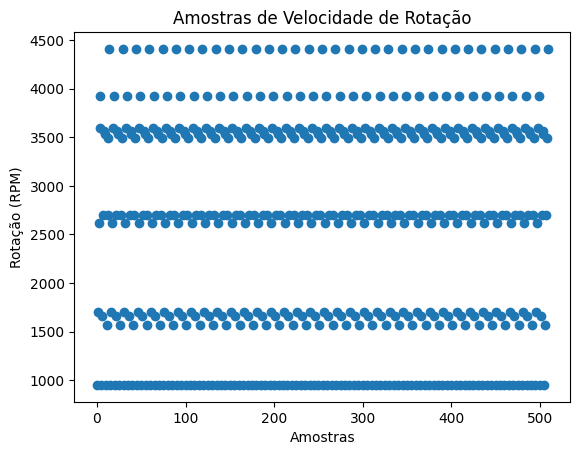

In [ ]:
a = df['Rotation'].tolist()
b =[]

for i in range(len(a)):
  b.append(i)

plt.scatter(b,a)
plt.title('Amostras de Velocidade de Rotação')
plt.xlabel('Amostras')
plt.ylabel('Rotação (RPM)')
plt.show()

Essa feature atua em múltiplas faixas, cada uma referente a um setpoint de rotação.

Será utilizado StandardScaler para essa variável.

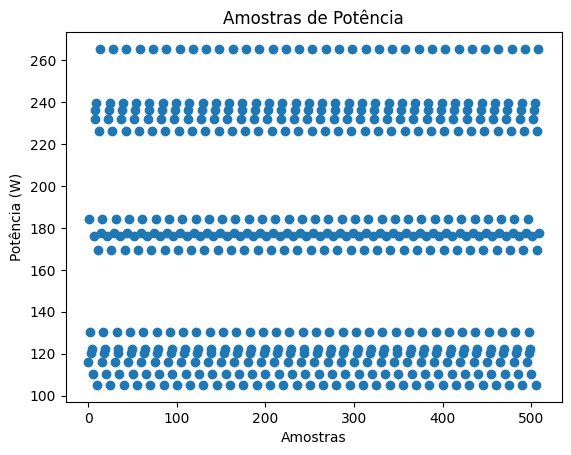

In [ ]:
a = df['Power'].tolist()
b =[]

for i in range(len(a)):
  b.append(i)

plt.scatter(b,a)
plt.title('Amostras de Potência')
plt.xlabel('Amostras')
plt.ylabel('Potência (W)')
plt.show()

Potência também atua em faixas mas há uma maior variabilidade dentro de cada uma.

Talvez, por conta dessa variabilidade, a melhor opção seja utilizar StandardScaler em sua escala

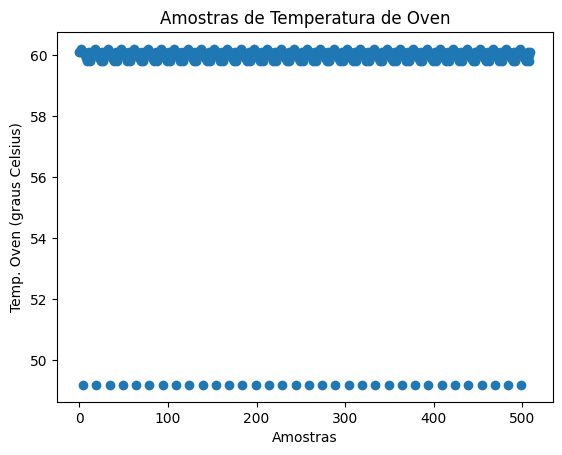

In [ ]:
a = df['Oven'].tolist()
b =[]

for i in range(len(a)):
  b.append(i)

plt.scatter(b,a)
plt.title('Amostras de Temperatura de Oven')
plt.xlabel('Amostras')
plt.ylabel('Temp. Oven (graus Celsius)')
plt.show()

Entre todas as observações, cada componente apresenta apenas UMA leitura com uma temperatura de `Oven` mais baixa e todas as outras na faixa de 60 graus.

Talvez faça sentido utlizar MinMaxScaler dado que haverão dois valores extremos

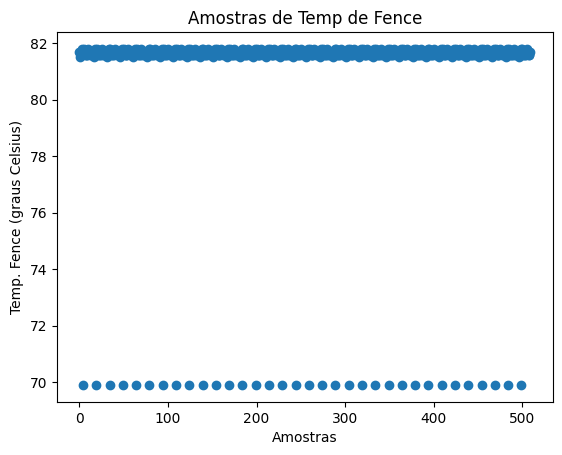

In [ ]:
a = df['Fence'].tolist()
b =[]

for i in range(len(a)):
  b.append(i)

plt.scatter(b,a)
plt.title('Amostras de Temp de Fence')
plt.xlabel('Amostras')
plt.ylabel('Temp. Fence (graus Celsius)')
plt.show()

A feature se comporta exatamente da mesma forma que `Oven`, portanto, receberá o mesmo tratamento e, em breve, testaremos se faz sentido retirar uma das duas do dataset.

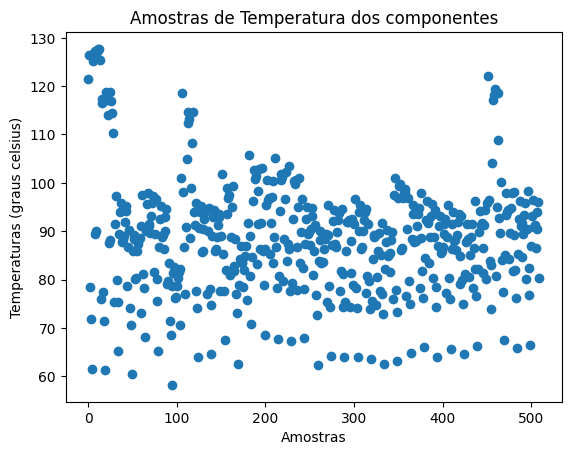

In [ ]:
a = df['Temperature'].tolist()
b =[]

for i in range(len(a)):
  b.append(i)

plt.scatter(b,a)
plt.title('Amostras de Temperatura dos componentes')
plt.xlabel('Amostras')
plt.ylabel('Temperaturas (graus celsius)')
plt.show()

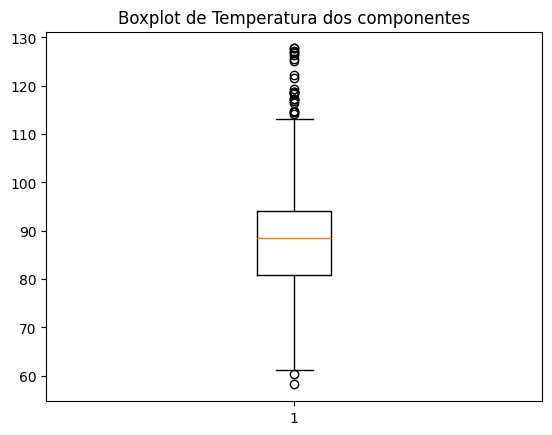

Existem 57 outliers na feature Temperature
Que representam 11.176470588235293% dos dados de temperaturas


In [ ]:
plt.boxplot(df['Temperature'])
plt.title('Boxplot de Temperatura dos componentes')
plt.show()

Q1 = df['Temperature'].quantile(0.25)
Q3 = df['Temperature'].quantile(0.75)

IQR = Q3 - Q1
a = 0

for i in range(len(df['Temperature'])):
  if df['Temperature'][i] < (Q1 - IQR) or df['Temperature'][i] > (Q3 + IQR):
    a+=1

print(f'Existem {a} outliers na feature Temperature')
print(f'Que representam {(a*100)/len(df['Temperature'])}% dos dados de temperaturas')

Podemos observar que a feature de Temperature possuem alguns outliers, correspondentes a aproximandamente 11% do dataset. Talvez o StandardScaler seja o suficiente para escalar essa variável, mas caso o modelo esteja com desempenho ruim, podemos testar o modelo com RobustScaler

###Análise de variável categórica

Agora todas as colunas foram convertidas em uma só previamente, portanto, não será necessário uma análise tão profunda dessas variáveis.

In [ ]:
componentes = df['Component geral'].unique()
print(componentes)

x = []
for i in range(len(componentes)):
  x.append(int(df['Component geral'][df['Component geral'] == componentes[i]].count()))

print(x)

['Power Switch - MOSFET IGB101  Tab'
 'Power Switch - MOSFET        IGB103        Tab\n'
 'IC - uC\tIC500\tTOP\r'
 'IC - Optocoupler - Ambient Temperature\tIC400\tTOP\r'
 'IC - SMPS Switcher\tIC502\tTOP\r' 'IC - Linear Regulator\tIC501\tTOP\r'
 'Conector - Comms\tCN209\tPlastic\r'
 'Diode - Rectifier Bridge\tD200\tSide. Above the hole\r'
 'Magnetic - SMPS Transformer\tL500\tTop\r'
 'Magnetic - SMPS Transformer\tL500\tWinding\r'
 'Capacitor - Bus eCap\tC203\tTOP\r'
 'Capacitor - EMI Input X Capacitor\tC201\tTOP\r'
 'Capacitor - EMI Post Choke X Capacitor\tC202\tTOP\r'
 'Capacitor - EMI Y capacitor\tC200\tTOP\r'
 'Magnetic - CMM Choke\tL200\tCore\r'
 'Magnetic - CMM Choke\tL200\tWinding\r' 'Relay\tK100\tTOP\r'
 'Relay\tK100\tPin - 1 +15V\r' 'Capacitor - 6V eCap\tC508\tTop\r'
 'Fuse - Input\tF200\tTOP\r' 'Capacitor - 15V eCap\tC504\tTOP\r'
 'Conector - Harmonics Inductor \tCN200\tTOP\r'
 'Fuse - DC Bus\tF201\tTOP\r' 'IC - OPAMP\tIC204\tTOP\r'
 'IC - Active Vibration\tIC300\tTOP\r' 'Resist

In [ ]:
len(x)

34

Há 34 categorias diferentes que se repetem 15 vezes cada uma, será utilizada uma camada de embedding com 6 dimensões

###Criação e treinamento da rede Neural

Aqui iremos criar e treinar um agente para previsão da temperatura dos componentes

####Primeiro a divisão em treino e teste

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(['Temperature'], axis = 1),df['Temperature'],
                                                    random_state = 42, test_size = 0.2)

Variáveis a serem escaladas com StandardScaler:

In [ ]:
rotation_scaler = StandardScaler()
power_scaler = StandardScaler()
y_scaler = StandardScaler()

x_train['Rotation'] = rotation_scaler.fit_transform(x_train[['Rotation']])
x_test['Rotation'] = rotation_scaler.transform(x_test[['Rotation']])

x_train['Power'] = power_scaler.fit_transform(x_train[['Power']])
x_test['Power'] = power_scaler.transform(x_test[['Power']])

y_train = pd.Series(y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten(), index=y_train.index, name='Temperature')
y_test = pd.Series(y_scaler.transform(y_test.values.reshape(-1, 1)).flatten(), index=y_test.index, name='Temperature')

Variáveis a serem escaladas com MinMaxScaler:

In [ ]:
oven_scaler = MinMaxScaler(feature_range=(-1,1))
fence_scaler = MinMaxScaler(feature_range=(-1,1))
voltage_scaler = MinMaxScaler(feature_range=(-1,1))

x_train['Voltage'] = voltage_scaler.fit_transform(x_train[['Voltage']])
x_test['Voltage'] = voltage_scaler.transform(x_test[['Voltage']])

x_train['Oven'] = oven_scaler.fit_transform(x_train[['Oven']])
x_test['Oven'] = oven_scaler.transform(x_test[['Oven']])

x_train['Fence'] = fence_scaler.fit_transform(x_train[['Fence']])
x_test['Fence'] = fence_scaler.transform(x_test[['Fence']])

####Criação da rede Neural e camada de embedding

In [ ]:
componente_index = df['Component geral'].astype('category').cat.codes
x_train_cat_codes = componente_index[x_train.index]
x_test_cat_codes = componente_index[x_test.index]

x_train_numerical = x_train.drop(['Component geral', 'Fence'], axis = 1)
x_test_numerical = x_test.drop(['Component geral', 'Fence'], axis = 1)

numerical_input = Input(shape = (4,))
categorical_input = Input(shape = (1,))

embedding = Embedding(input_dim = 34, output_dim= 6)(categorical_input)
flatten_layer = Flatten()(embedding)

concatenated_inputs = Concatenate()([numerical_input,flatten_layer])

dense1 = Dense(128, activation = 'relu')(concatenated_inputs)
dense2 = Dense(128, activation = 'relu')(dense1)
#dense3 = Dense(39, activation = 'relu')(dense2)

output_layer = Dense(1, activation = None)(dense2)

modelo2 = Model(inputs = [numerical_input,categorical_input], outputs = output_layer)

modelo2.compile(optimizer = 'adam', loss = 'mean_absolute_error')

early_stopping = EarlyStopping(monitor = 'val_loss', patience = 20, restore_best_weights = True)
lr_scheduler = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.1, patience = 15,)

modelo2.fit(
    x = [x_train_numerical, x_train_cat_codes],
    y = y_train,
    validation_data = ([x_test_numerical, x_test_cat_codes], y_test),
    validation_split = 0.2,
    epochs = 150,
    batch_size = 30,
    callbacks = [early_stopping, lr_scheduler],
    verbose = 1
)

Epoch 1/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.6401 - val_loss: 0.4165 - learning_rate: 0.0010
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4476 - val_loss: 0.3553 - learning_rate: 0.0010
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4130 - val_loss: 0.3397 - learning_rate: 0.0010
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3983 - val_loss: 0.3299 - learning_rate: 0.0010
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3863 - val_loss: 0.3097 - learning_rate: 0.0010
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3628 - val_loss: 0.2910 - learning_rate: 0.0010
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3318 - val_loss: 0.2722 - learning_rate: 0.0010
Epoch 8/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2986 - val_loss: 0.2475 - learning_rate: 0.0010
Epoch 9/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2655 - val_loss: 0.2369 - learning_rate: 0.0010
Epoch 10/150
14/1

In [ ]:
test_mae = modelo2.evaluate([x_test_numerical, x_test_cat_codes], y_test, verbose=0)
print(f"Mean Absolute Error no teste: {test_mae:.4f}") # Pontuação final da MAE em relação ao teste

Mean Absolute Error no teste: 0.0370


In [ ]:
y_pred = modelo2.predict([x_test_numerical, x_test_cat_codes])

y_pred = y_scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_original = y_scaler.inverse_transform(y_test.values.reshape(-1, 1))

mape = mean_absolute_percentage_error(y_test_original, y_pred)
print(f'Mean absolute percentage error do modelo 2 é {mape:.2%}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Mean absolute percentage error do modelo 2 é 0.49%


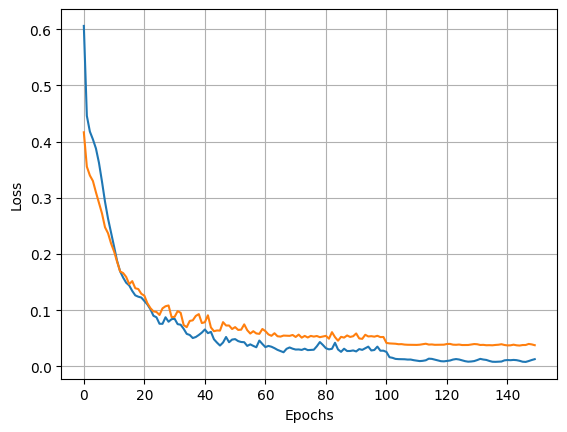

In [ ]:
plt.plot(modelo2.history.history['loss'], label = 'loss_modelo2')# history.history é o histórico do modelo, 'val_loss' é o conjunto dos erros de treino
plt.plot(modelo2.history.history['val_loss'], label = 'val_loss_modelo2')# history.history é o histórico do modelo, 'val_loss' é o conjunto dos erros de validação
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
#plt.legend()

plt.grid(True)
plt.show()

**Análise gráfica**: podemos observar que o modelo também não apresentou overfit, pois ambas as curvas seguiram o mesmo padrão de decrescimento e estabilização, apesar do erro de treino estar menos, o que é algo normal

Relembrando que esse erro de 0.49%, trata-se de um erro **MÉDIO**, apesar de ser um resultado extremamente preciso, haverá faixas que o erro será um pouco maior e outras onde ele será até mais preciso

Para o modelo treinado com base nos testes de potência máxima, retirar a feature `Voltage`, não foi tão vantajoso quanto para os demais modelos, entretanto, ao retirar `Fence`, ele obteve performance superior

###Código para previsão de temperaturas

####Código para identificação de ids de componentes:

In [ ]:
##código para identificar o id de cada componente
componente_idx = df['Component geral'].astype('category').cat.codes
a = {}

for i in range(len(componente_idx)):
  a[df['Component geral'][i]] = int(componente_idx[i])

print(a)

{'Power Switch - MOSFET IGB101  Tab': 29, 'Power Switch - MOSFET        IGB103        Tab\n': 28, 'IC - uC\tIC500\tTOP\r': 21, 'IC - Optocoupler - Ambient Temperature\tIC400\tTOP\r': 19, 'IC - SMPS Switcher\tIC502\tTOP\r': 20, 'IC - Linear Regulator\tIC501\tTOP\r': 17, 'Conector - Comms\tCN209\tPlastic\r': 9, 'Diode - Rectifier Bridge\tD200\tSide. Above the hole\r': 12, 'Magnetic - SMPS Transformer\tL500\tTop\r': 24, 'Magnetic - SMPS Transformer\tL500\tWinding\r': 25, 'Capacitor - Bus eCap\tC203\tTOP\r': 4, 'Capacitor - EMI Input X Capacitor\tC201\tTOP\r': 5, 'Capacitor - EMI Post Choke X Capacitor\tC202\tTOP\r': 6, 'Capacitor - EMI Y capacitor\tC200\tTOP\r': 7, 'Magnetic - CMM Choke\tL200\tCore\r': 22, 'Magnetic - CMM Choke\tL200\tWinding\r': 23, 'Relay\tK100\tTOP\r': 31, 'Relay\tK100\tPin - 1 +15V\r': 30, 'Capacitor - 6V eCap\tC508\tTop\r': 3, 'Fuse - Input\tF200\tTOP\r': 14, 'Capacitor - 15V eCap\tC504\tTOP\r': 2, 'Conector - Harmonics Inductor \tCN200\tTOP\r': 10, 'Fuse - DC Bus\tF

In [ ]:
##Código para previsão de pontos futuros

#aqui inserimos os dados desejados
input_voltage = 264.32
input_rotation = 4410
input_power = 177.5
input_oven = 60.1
input_component_code = 1

print(f"Original input values:Voltage = {input_voltage}, Rotation={input_rotation}, Power={input_power}, Oven={input_oven}, Component Code={input_component_code}")

##aqui escalamos os dados inseridos para se adequarem à escala realizada
scaled_voltage = voltage_scaler.transform(pd.DataFrame([[input_voltage]], columns=['Voltage']))[0][0]
scaled_rotation = rotation_scaler.transform(pd.DataFrame([[input_rotation]], columns=['Rotation']))[0][0]
scaled_power = power_scaler.transform(pd.DataFrame([[input_power]], columns=['Power']))[0][0]
scaled_oven = oven_scaler.transform(pd.DataFrame([[input_oven]], columns=['Oven']))[0][0]


specific_numerical_input = np.array([[scaled_voltage, scaled_rotation, scaled_power, scaled_oven]])

specific_categorical_input = np.array([[input_component_code]])

print(f"\nScaled Numerical Input: {specific_numerical_input}")
print(f"Categorical Input Code: {specific_categorical_input}")

#aqui o modelo treinado faz a previsão de acordo com os dados de entrada escalados
predicted_scaled_temperature = modelo2.predict([
    specific_numerical_input,
    specific_categorical_input
])

#temperatura transformada de volta à escala normal
predicted_original_temperature = y_scaler.inverse_transform(predicted_scaled_temperature.reshape(-1, 1))

#print da temperatura prevista escalada e na escala real
print(f"\nPredicted Temperature (scaled): {predicted_scaled_temperature[0][0]:.4f}")
print(f"Predicted Temperature (original scale): {predicted_original_temperature[0][0]:.2f} °C")

Original input values:Voltage = 264.32, Rotation=4410, Power=177.5, Oven=60.1, Component Code=1

Scaled Numerical Input: [[1.         1.6316581  0.04866417 0.98181818]]
Categorical Input Code: [[1]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

Predicted Temperature (scaled): -0.6581
Predicted Temperature (original scale): 80.49 °C


###Heatmap de erro máximo por componente por faixas de Tensão

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


/tmp/ipython-input-3275516797.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Component geral", "V_range"])["error"]
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


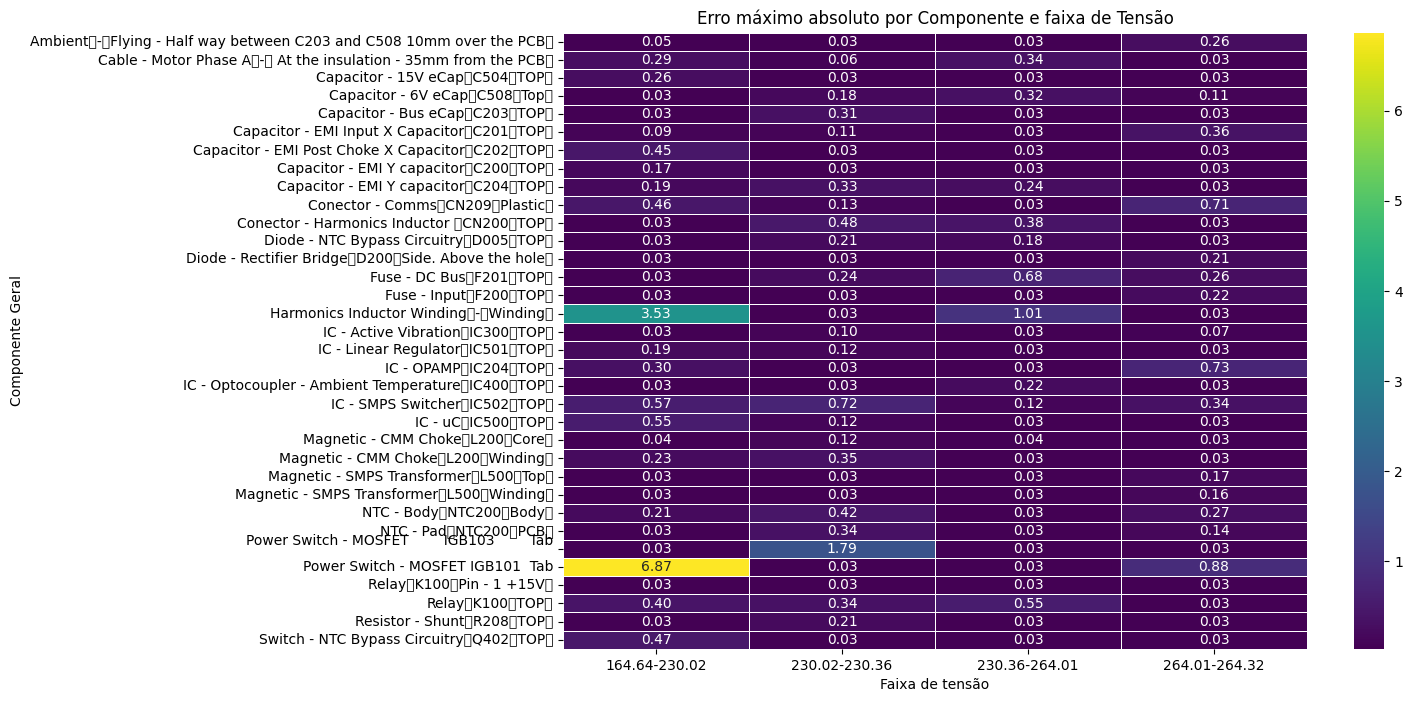

In [ ]:
#Aqui criamos uma tabela que nos informa o erro máximo absoluto para duas faixas de tensão
# Dessa forma haverá mais certeza se para a faixa escolhida de predição, o modelo conseguirá fazer uma boa aproximação


bins = [164.64, 230.02, 230.36, 264.01, 264.32]
labels = ['164.64-230.02', '230.02-230.36', '230.36-264.01', '264.01-264.32']
df["V_range"] = pd.cut(df["Voltage"], bins=bins, labels=labels, include_lowest=True)

y_true_temp = pd.Series(y_scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten(), index=y_test.index)
df["y_true"] = y_true_temp.reindex(df.index, fill_value=0)

y_pred_temp = pd.Series(y_scaler.inverse_transform(modelo2.predict([x_test_numerical, x_test_cat_codes])).flatten(), index=y_test.index)
df["y_pred"] = y_pred_temp.reindex(df.index, fill_value=0.03)

# Erro  absoluto
df["error"] = np.abs(df["y_pred"] - df["y_true"])
# Agrupar por componente + faixa, calculando o ERRO MÁXIMO
error_table = (
    df.groupby(["Component geral", "V_range"])["error"]
    .max()
    .reset_index()
)


pivot = error_table.pivot(
    index="Component geral",
    columns="V_range",
    values="error"
)


plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Erro máximo absoluto por Componente e faixa de Tensão')
plt.xlabel('Faixa de tensão')
plt.ylabel('Componente Geral')
plt.show()

Esse mapa de calor é feito em relação às faixas da feature com menor correlção com a variável alvo. Garantindo dessa forma maior precisão, visto que essa feature é a que mais contribui para a instabilidade do modelo